<a href="https://colab.research.google.com/github/Jenifar5/Applied-ai/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload an image (single image with multiple faces is fine)


Saving download (2).jpg to download (2).jpg
Detected 8 face(s)


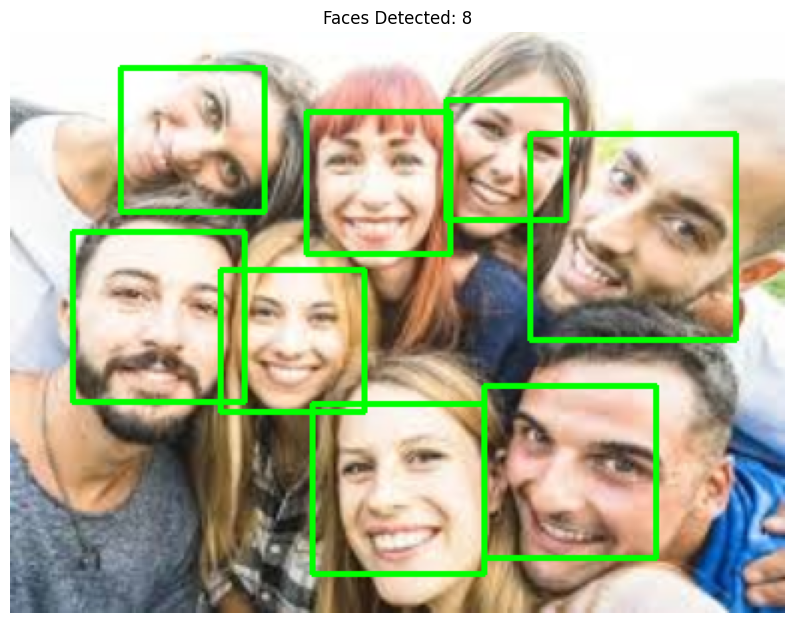

In [2]:
import dlib
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import urllib.request
import bz2
model_url = "http://dlib.net/files/mmod_human_face_detector.dat.bz2"
urllib.request.urlretrieve(model_url, "mmod_human_face_detector.dat.bz2")
with bz2.open("mmod_human_face_detector.dat.bz2", "rb") as f:
    with open("mmod_human_face_detector.dat", "wb") as out:
        out.write(f.read())
cnn_detector = dlib.cnn_face_detection_model_v1("mmod_human_face_detector.dat")
print("Upload an image (single image with multiple faces is fine)")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
img = cv2.imread(image_path)
scale = 1.5
img = cv2.resize(img, None, fx=scale, fy=scale)
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
faces = cnn_detector(rgb, 2)
print(f"Detected {len(faces)} face(s)")
for face in faces:
    rect = face.rect
    x, y, w, h = rect.left(), rect.top(), rect.width(), rect.height()
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Faces Detected: {len(faces)}")
plt.axis('off')
plt.show()